In [252]:
import glob
import os
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
from IPython.display import display

import ldparser
from ldparser import ldData

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import silhouette_score

In [253]:
ld_data = glob.glob("raw_data/*.ld")
print(f"[Info] {len(ld_data)} Telemetriedateien im Ordner gefunden.")

channel_tuple_mapping = {
    'Steering Angle': 'steering_angle',
    'Throttle Pos': 'throttle_pos',
    'Brake Pos': 'brake_pos',
    'Engine RPM': 'engine_rpm',
    'Wheel Angular Speed FL': 'speed_fl',
}

[Info] 25 Telemetriedateien im Ordner gefunden.


In [254]:
master_feature_liste = []

for ld_file in ld_data:
    timestamp_in_seconds = []
    ldx_file = ld_file.replace('.ld', '.ldx')

    # LDX-Datei einlesen und Zeitstempel der Beacons extrahieren
    try: 
        ldx_file_tree = ET.parse(ldx_file)
        ldx_file_root = ldx_file_tree.getroot()

        for beacon in ldx_file_root.findall('.//MarkerGroup[@Name="Beacons"]/Marker'):
            time_node = beacon.get('Time')

            if time_node is not None:
                time_node_in_seconds = float(time_node) / 1000000.0
                timestamp_in_seconds.append(time_node_in_seconds)
    except Exception as e:
        print(f"\n{e}")

    # LD-Datei einlesen und relevante Kanäle extrahieren
    telemetry_tuple = ldData.fromfile(ld_file)
    channel_data = {}
    for ld_name, htf_name in channel_tuple_mapping.items():
        
        if ld_name in telemetry_tuple:
            channel_object = telemetry_tuple[ld_name]
            channel_data[htf_name] = pd.Series(data=channel_object.data, index=np.arange(len(channel_object.data)) / getattr(channel_object, 'freq'))

            df_telemetry = pd.DataFrame(channel_data)

        else:
            print(f"\n{e}")
    

    for i in range(len(timestamp_in_seconds) - 1):
        # Zeit der Fahrer pro Rundenabschnitt extrahieren
        start_time = timestamp_in_seconds[i]
        end_time = timestamp_in_seconds[i + 1]
        
        curve_data = df_telemetry[(df_telemetry.index >= start_time) & (df_telemetry.index < end_time)]
        if curve_data.empty:
            continue

        # Fahrer-ID aus dem Dateinamen extrahieren
        file_name = os.path.basename(ld_file)
        data_name_parted = file_name.split('_&_')
        
        if len(data_name_parted) >= 3:
            driver_id = data_name_parted[2]
        else:
            driver_id = file_name
            
        feature = {
            'Fahrer_ID': driver_id,
            'Segment_Nummer': i + 1,

            # Die biometrischen Features (Mensch)
            'lenkung_unruhe': curve_data['steering_angle'].var() if 'steering_angle' in curve_data else 0,
            'gas_schnitt': curve_data['throttle_pos'].mean() if 'throttle_pos' in curve_data else 0,
            'gas_streuung': curve_data['throttle_pos'].var() if 'throttle_pos' in curve_data else 0,
            'brems_haerte': curve_data['brake_pos'].max() if 'brake_pos' in curve_data else 0,
            'brems_streuung': curve_data['brake_pos'].var() if 'brake_pos' in curve_data else 0,
            'drehzahl_schnitt': curve_data['engine_rpm'].mean() if 'engine_rpm' in curve_data else 0,

            # Die Physik-Kontext
            'geschw_schnitt': curve_data['speed_fl'].mean() if 'speed_fl' in curve_data else 0,
            'geschw_streuung': curve_data['speed_fl'].var() if 'speed_fl' in curve_data else 0,
        }
        master_feature_liste.append(feature)

df_master_ml = pd.DataFrame(master_feature_liste)
display(df_master_ml)

,Fahrer_ID,Segment_Nummer,lenkung_unruhe,gas_schnitt,gas_streuung,brems_haerte,brems_streuung,drehzahl_schnitt,geschw_schnitt,geschw_streuung
0,KEPD180,1,2178.967979,30.276085,491.698427,62.645714,169.586153,6488.723064,82.995369,1066.030572
1,KEPD180,2,1512.884081,33.840939,568.319213,64.275714,198.032419,6484.206040,84.985958,900.294745
2,KEPD180,3,1234.882773,33.025186,513.401169,88.424286,225.734819,6655.333700,87.990162,741.064056
3,KEPD180,4,2143.910024,35.785651,578.534677,76.600000,230.704524,5815.048329,85.629013,799.410694
4,KEPD180,5,1242.765028,35.532091,650.264238,81.305714,232.195841,5821.844547,85.949598,845.635448
...,...,...,...,...,...,...,...,...,...,...
139,OLOT290,2,810.927067,35.149509,1178.952369,47.760000,51.999980,6157.233307,49.617043,760.788759
140,OLOT290,3,544.069920,32.932558,1116.468451,59.605000,89.706292,5873.094271,63.525495,441.321581
141,OLOT290,4,553.658083,37.736827,1525.412639,50.415000,79.794298,5703.443397,60.574651,474.290883
142,OLOT290,5,463.452172,35.806458,1350.972643,52.485000,66.558296,5982.268264,64.756866,439.070692


In [255]:
# =========================================================================
# DIE RUNDEN-SÄUBERUNG (AUTOMATISCHE OUTLIER-FILTERUNG PER FAHRER)
# =========================================================================
import pandas as pd
import numpy as np

print(f"[Data-Cleaning] Datensatz VOR der Bereinigung: {df_master_ml.shape[0]} Zeilen")

# Sicherheitskopie für den Vorher-Nachher-Vergleich
df_vorher = df_master_ml.copy()

# Liste für die bereinigten Datenpakete der einzelnen Fahrer
bereinigte_fahrer_dfs = []

# Wir gehen jeden Fahrer einzeln durch, um seine persönliche Baseline zu schützen
for fahrer_id, fahrer_gruppe in df_master_ml.groupby('Fahrer_ID'):
    
    # --- ANSATZ A: Falls du eine explizite Rundenzeit-Spalte im DataFrame hast ---
    # (Ersetze 'Rundenzeit' durch deinen exakten Spaltennamen, falls vorhanden)
    if 'Rundenzeit' in fahrer_gruppe.columns:
        persoenliche_bestzeit = fahrer_gruppe['Rundenzeit'].min()
        # Maximal 5% Abweichung von der persönlichen Bestzeit erlaubt (In-/Out-Laps fliegen raus)
        toleranz_grenze = persoenliche_bestzeit * 1.05 
        fahrer_gruppe = fahrer_gruppe[fahrer_gruppe['Rundenzeit'] <= toleranz_grenze]
        
    # --- ANSATZ B: Statistischer IQR-Filter auf fahrphysikalische Kern-Features ---
    # Falls keine Rundenzeit da ist, filtern wir extreme Anomalien (z.B. Stehen in der Box, Boxenrunde)
    # über die Streuung von Vollgas-Anteil und Fliehkräften aus.
    else:
        # Wir picken uns 2-3 Kernfeatures heraus, die bei einer Boxenrunde komplett einbrechen
        fokus_features = [ 
            'brems_streuung', 
            'gas_streuung', 
            'geschw_streuung',
        ]
        
        for col in fokus_features:
            if col in fahrer_gruppe.columns:
                # Berechne das 25%- und 75%-Quartil des jeweiligen Fahrers
                Q1 = fahrer_gruppe[col].quantile(0.25)
                Q3 = fahrer_gruppe[col].quantile(0.75)
                IQR = Q3 - Q1
                
                # Wer mehr als 1.5 * IQR nach unten abweicht (z.B. kaum Gas gegeben, weil Boxenrunde), fliegt raus
                untere_grenze = Q1 - 1.5 * IQR
                # Wer extrem nach oben abweicht (z.B. Messfehler), fliegt ebenfalls raus
                obere_grenze = Q3 + 1.5 * IQR
                
                fahrer_gruppe = fahrer_gruppe[(fahrer_gruppe[col] >= untere_grenze) & (fahrer_gruppe[col] <= obere_grenze)]
                
    bereinigte_fahrer_dfs.append(fahrer_gruppe)

# Alle bereinigten Fahrer-Pakete wieder zu einem großen Master-DataFrame zusammenbauen
df_master_ml = pd.concat(bereinigte_fahrer_dfs, ignore_index=True)

# Abschluss-Report ausgeben
entfernte_runden = df_vorher.shape[0] - df_master_ml.shape[0]
print(f"[Data-Cleaning] Datensatz NACH der Bereinigung: {df_master_ml.shape[0]} Zeilen")
print(f"[Data-Cleaning] Erfolg! {entfernte_runden} unrepräsentative Runden/Ausreißer wurden eliminiert.")

[Data-Cleaning] Datensatz VOR der Bereinigung: 144 Zeilen
[Data-Cleaning] Datensatz NACH der Bereinigung: 116 Zeilen
[Data-Cleaning] Erfolg! 28 unrepräsentative Runden/Ausreißer wurden eliminiert.


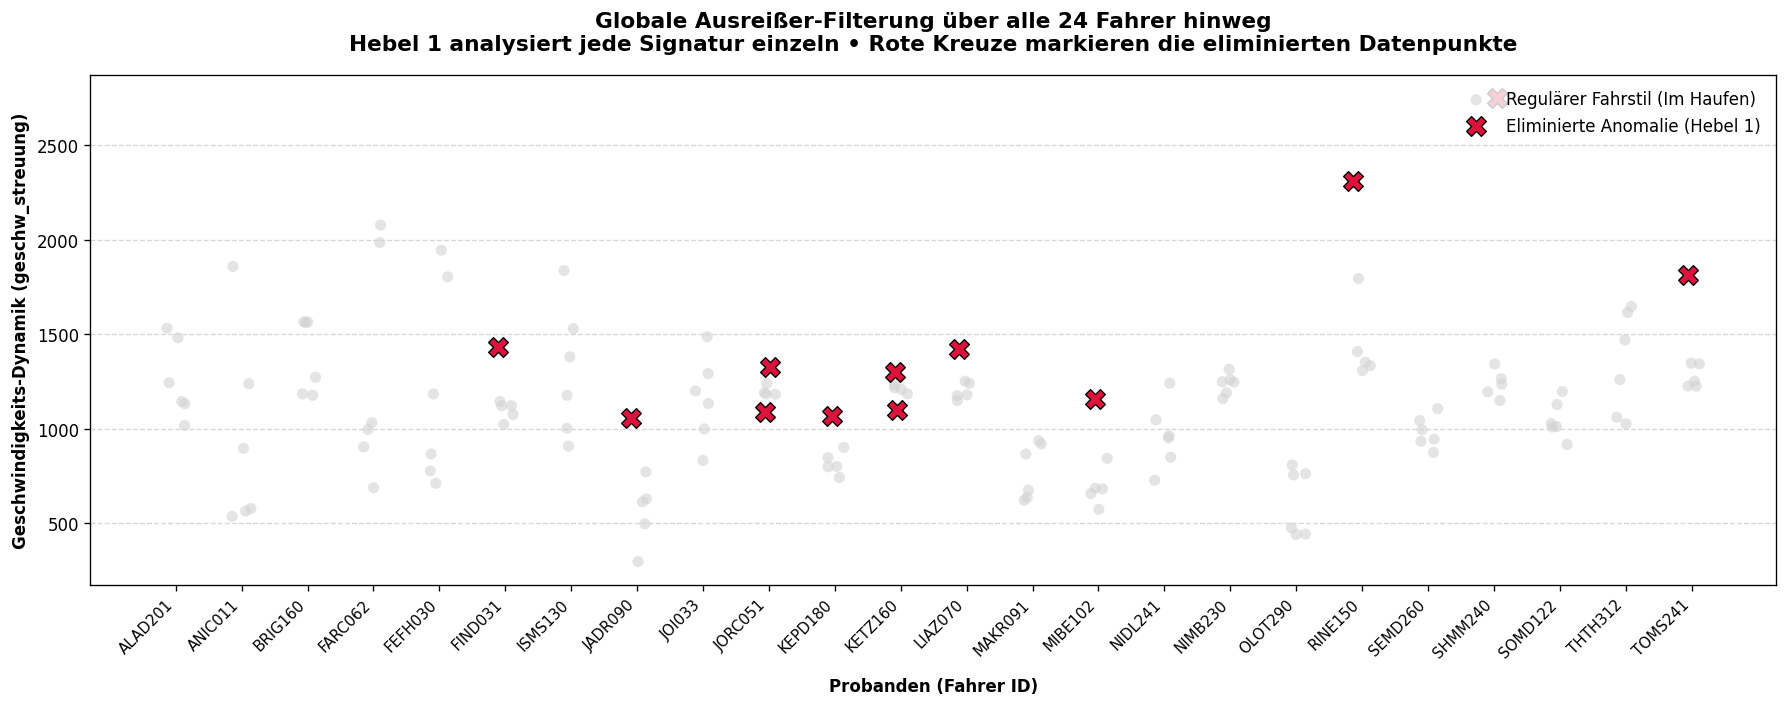

In [256]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Feature festlegen
feature = 'geschw_streuung'

# 2. Wir erstellen eine Kopie der Originaldaten und fügen eine Ausreißer-Spalte hinzu
df_global_plot = df_vorher.copy()
df_global_plot['Is_Outlier'] = False

# 3. Wir berechnen den IQR-Filter für JEDEN der 25 Fahrer einzeln
for fahrer_id, fahrer_gruppe in df_global_plot.groupby('Fahrer_ID'):
    if feature in fahrer_gruppe.columns:
        Q1 = fahrer_gruppe[feature].quantile(0.25)
        Q3 = fahrer_gruppe[feature].quantile(0.75)
        IQR = Q3 - Q1
        untere_grenze = Q1 - 1.5 * IQR
        obere_grenze = Q3 + 1.5 * IQR
        
        # Maske für die Ausreißer dieses spezifischen Fahrers
        outlier_mask = (fahrer_gruppe[feature] < untere_grenze) | (fahrer_gruppe[feature] > obere_grenze)
        # Im globalen DataFrame markieren
        df_global_plot.loc[fahrer_gruppe[outlier_mask].index, 'Is_Outlier'] = True

# 4. Sortierte Fahrer-Liste für die X-Achse vorbereiten
unique_drivers = sorted(df_global_plot['Fahrer_ID'].unique())
driver_to_idx = {d: i for i, d in enumerate(unique_drivers)}
df_global_plot['Fahrer_Idx'] = df_global_plot['Fahrer_ID'].map(driver_to_idx)

# 5. Ein bisschen "Jitter" (Zufalls-Verschiebung nach links/rechts) hinzufügen,
# damit Punkte auf der gleichen X-Achse nicht exakt übereinanderkleben
np.random.seed(42)
df_global_plot['X_Jittered'] = df_global_plot['Fahrer_Idx'] + np.random.uniform(-0.15, 0.15, len(df_global_plot))

# 6. Den globalen Graphen initialisieren
fig, ax = plt.subplots(figsize=(15, 6), dpi=120)

# A) Die treuen, normalen Runden im Hintergrund (Dezent in Hellgrau)
normal_data = df_global_plot[~df_global_plot['Is_Outlier']]
ax.scatter(
    normal_data['X_Jittered'], normal_data[feature], 
    color='lightgray', alpha=0.6, s=45, label='Regulärer Fahrstil (Im Haufen)', edgecolors='none', zorder=2
)

# B) NUR DIE RAUSGESCHMISSENEN WERTE MARKIEREN (In fettem Signal-Rot)
outlier_data = df_global_plot[df_global_plot['Is_Outlier']]
ax.scatter(
    outlier_data['X_Jittered'], outlier_data[feature], 
    color='crimson', marker='X', s=140, label='Eliminierte Anomalie (Hebel 1)', edgecolors='black', linewidths=0.8, zorder=5
)

# Styling für maximale Übersicht bei 25 Klassen
ax.set_title(f"Globale Ausreißer-Filterung über alle {len(unique_drivers)} Fahrer hinweg\n"
             f"Hebel 1 analysiert jede Signatur einzeln • Rote Kreuze markieren die eliminierten Datenpunkte", 
             fontweight='bold', fontsize=13, pad=15)
ax.set_xlabel("Probanden (Fahrer ID)", fontweight='bold', labelpad=10)
ax.set_ylabel("Geschwindigkeits-Dynamik (geschw_streuung)", fontweight='bold')

# X-Achsen-Beschriftung sauber verteilen und rotieren
ax.set_xticks(range(len(unique_drivers)))
ax.set_xticklabels(unique_drivers, rotation=45, ha='right', fontsize=9)

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Abspeichern für deine Präsentation / Thesis
plt.savefig("hebel1_global_outlier_plot.png", bbox_inches='tight', dpi=300)


--- STATISTISCHER REPORT FÜR DEINE THESIS ---
Hauptkomponente 1 (PC1): Erklärt 46.0% der gesamten Fahrer-Unterschiede.
Hauptkomponente 2 (PC2): Erklärt 16.7% der gesamten Fahrer-Unterschiede.
Hauptkomponente 3 (PC3): Erklärt 12.7% der gesamten Fahrer-Unterschiede.
-> Gesamte erklärte Wahrheit im 3D-Raum: 75.5%
-------------------------------------------------



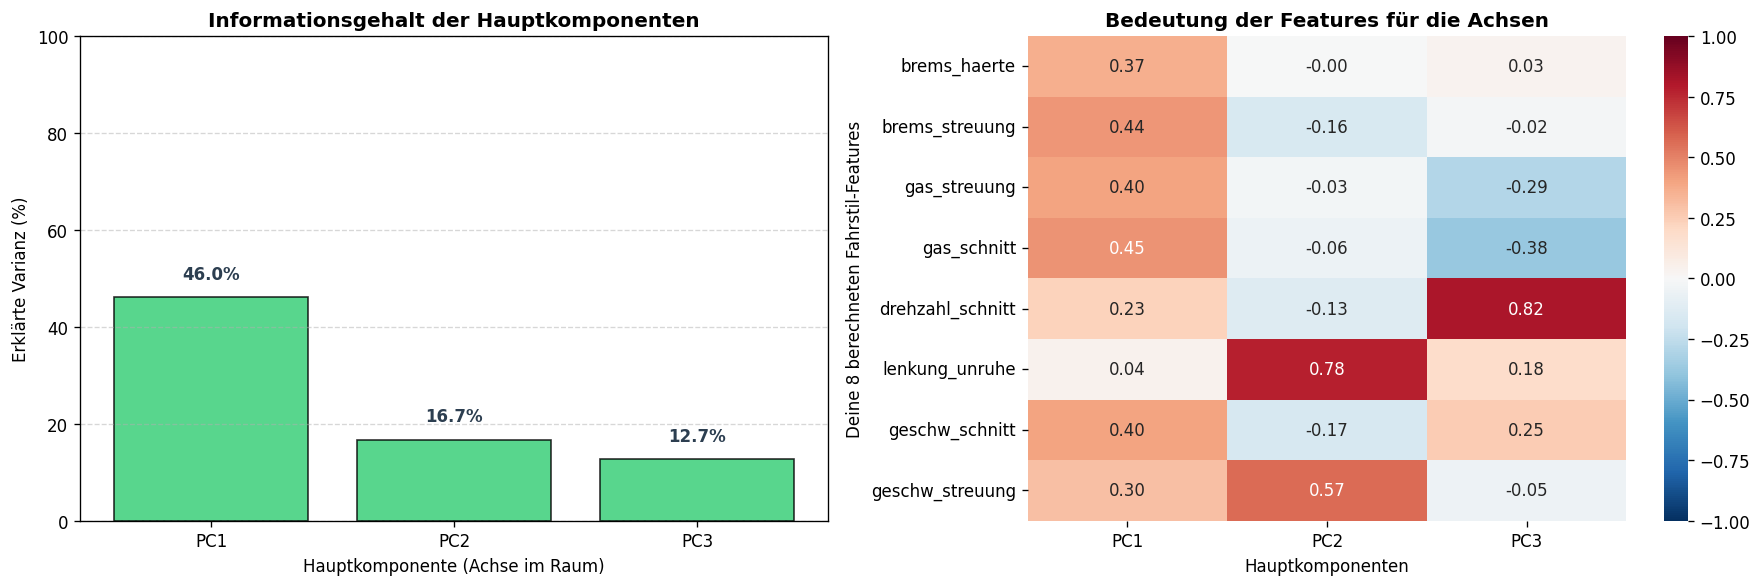

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

try:
    # 1. Reine Feature-Matrix isolieren (Metadaten weglassen)
    spalten_fuer_pca = [ 
        'brems_haerte', 'brems_streuung', 
        'gas_streuung', 'gas_schnitt', 
        'drehzahl_schnitt', 'lenkung_unruhe', 
        'geschw_schnitt', 'geschw_streuung',
    ]
    
    # Prüfen, ob alle Spalten da sind
    vorhandene_features = [f for f in spalten_fuer_pca if f in df_master_ml.columns]
    X_pca_input = df_master_ml[vorhandene_features]

    # 2. Skalierung (Absolut Pflicht vor einer PCA!)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_pca_input)

    # 3. PCA berechnen (Wir schauen uns die ersten 3 Hauptkomponenten an)
    pca = PCA(n_components=3)
    X_projected = pca.fit_transform(X_scaled)
    var_exp = pca.explained_variance_ratio_

    # --- TEXT-REPORT FÜR DEINE UNTERLAGEN ---
    print("\n--- STATISTISCHER REPORT FÜR DEINE THESIS ---")
    for idx, anteil in enumerate(var_exp):
        print(f"Hauptkomponente {idx+1} (PC{idx+1}): Erklärt {anteil*100:.1f}% der gesamten Fahrer-Unterschiede.")
    print(f"-> Gesamte erklärte Wahrheit im 3D-Raum: {sum(var_exp)*100:.1f}%")
    print("-------------------------------------------------\n")

    # --- GRAFIK 1: DER SCREE-PLOT (Erklärte Varianz) ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=120)
    
    komponenten_labels = [f"PC{i+1}" for i in range(len(var_exp))]
    bars = ax1.bar(komponenten_labels, var_exp * 100, color='#2ecc71', edgecolor='k', alpha=0.8)
    ax1.set_title("Informationsgehalt der Hauptkomponenten", fontweight='bold', fontsize=12)
    ax1.set_xlabel("Hauptkomponente (Achse im Raum)")
    ax1.set_ylabel("Erklärte Varianz (%)")
    ax1.set_ylim(0, 100)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Prozentzahlen auf die Säulen schreiben
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 3, f"{height:.1f}%", 
                 ha='center', va='bottom', fontweight='bold', color='#2c3e50')

    # --- GRAFIK 2: FEATURE LOADINGS HEATMAP (Deine Feature-Vorstellung!) ---
    # Hier wird berechnet, wie stark jedes deiner 8 Features auf die Achsen abfärbt
    loadings = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC1', f'PC2', f'PC3'], 
        index=vorhandene_features
    )
    
    sns.heatmap(loadings, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f", ax=ax2, cbar=True)
    ax2.set_title("Bedeutung der Features für die Achsen", fontweight='bold', fontsize=12)
    ax2.set_ylabel("Deine 8 berechneten Fahrstil-Features")
    ax2.set_xlabel("Hauptkomponenten")
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Fehler bei der Varianz-Analyse: {e}")

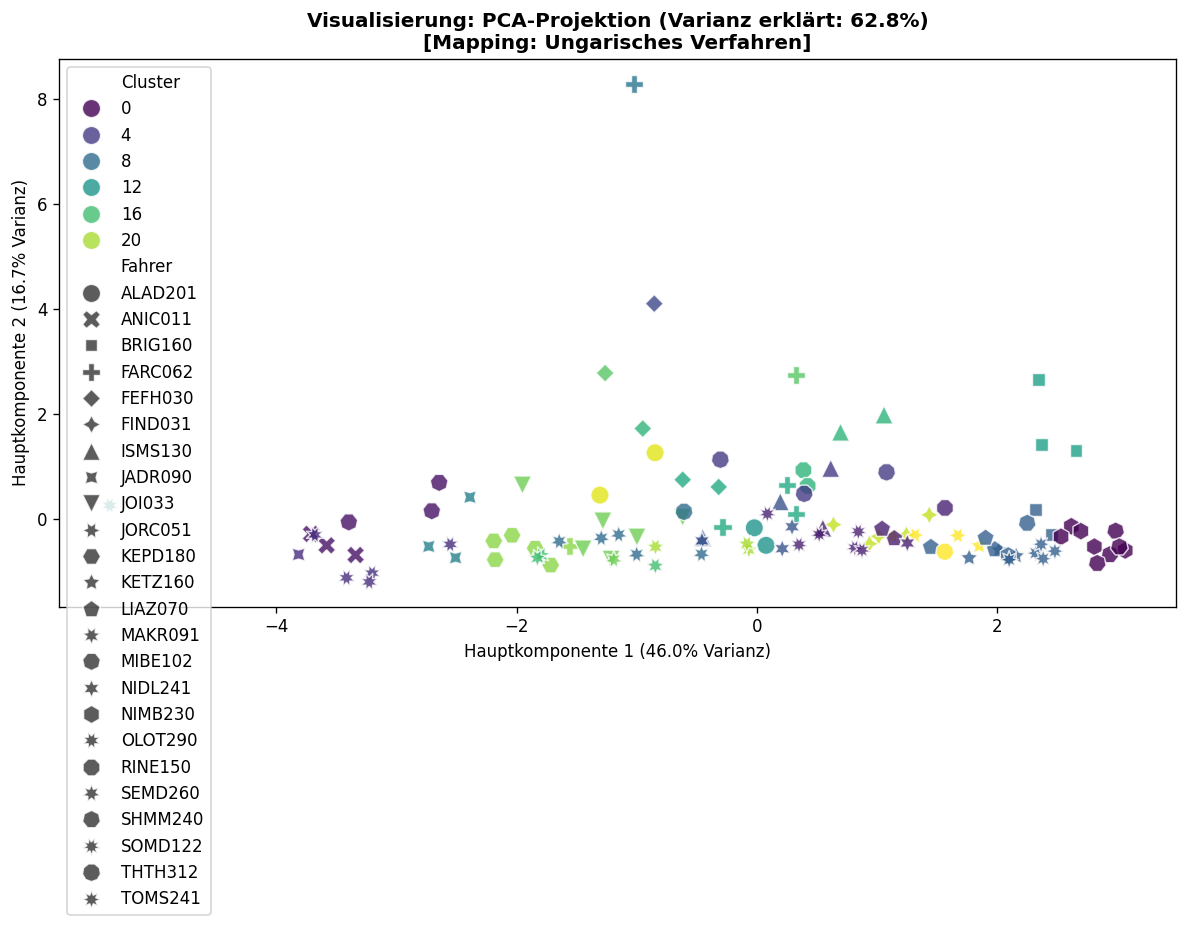

Silhouette Score (Qualität der Trennung): 0.290


In [258]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment

try: 
    # 1. Daten vorbereiten (Zusätzliche Sicherheits-Drops, falls die Zelle mehrfach läuft)
    spalten_zum_loeschen = [
        'Fahrer_ID', 'Segment_Nummer', 'Fahrstil_Cluster_ID', 
        'Vorhergesagter_Fahrer', 'Vorhergesagter_Cluster', 'Erkannter_Fahrer'
    ]
    x_clustering = df_master_ml.drop(columns=spalten_zum_loeschen, errors='ignore')

    # 2. Skalieren (WICHTIG für K-Means und PCA!)
    scaler = StandardScaler()
    x_scaled = scaler.fit_transform(x_clustering)

    # 3. K-Means Training (Wir nehmen die Anzahl der Fahrer als Cluster-Anzahl)
    num_drivers = df_master_ml['Fahrer_ID'].nunique()
    kmeans_final = KMeans(n_clusters=num_drivers, random_state=42, n_init=100)
    df_master_ml['Fahrstil_Cluster_ID'] = kmeans_final.fit_predict(x_scaled)

    # ungarische Methode
    contingency_matrix = pd.crosstab(df_master_ml['Fahrer_ID'], df_master_ml['Fahrstil_Cluster_ID'])
    cost_matrix = -contingency_matrix.values
    fahrer_indizes, cluster_indizes = linear_sum_assignment(cost_matrix)

    # konfliktfreie 1-zu-1 Mapping-Wörterbuch befüllen
    cluster_to_driver = {}
    for f_idx, c_idx in zip(fahrer_indizes, cluster_indizes):
        echter_fahrer_name = contingency_matrix.index[f_idx]
        cluster_id = contingency_matrix.columns[c_idx]
        cluster_to_driver[cluster_id] = echter_fahrer_name
        
    # Zuweisung auf das Master-DataFrame anwenden
    df_master_ml['Vorhergesagter_Fahrer'] = df_master_ml['Fahrstil_Cluster_ID'].map(cluster_to_driver)
    
    # PCA zur Visualisierung (Dimensionalitätsreduktion)
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(x_scaled)
    df_pca = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])
    df_pca['Fahrer'] = df_master_ml['Fahrer_ID'].values
    df_pca['Cluster'] = df_master_ml['Fahrstil_Cluster_ID'].values

    # Plotten
    plt.figure(figsize=(10, 7), dpi=120)
    sns.scatterplot(
        data=df_pca,
        x='PC1',
        y='PC2',
        hue='Cluster',
        style='Fahrer',
        palette='viridis',
        s=120,
        alpha=0.8
    )
    
    # Erklärte Varianz anzeigen (sehr wichtig für die Thesis!)
    var_exp = pca.explained_variance_ratio_
    plt.title(f"Visualisierung: PCA-Projektion (Varianz erklärt: {sum(var_exp):.1%})\n[Mapping: Ungarisches Verfahren]", fontweight='bold')
    plt.xlabel(f"Hauptkomponente 1 ({var_exp[0]:.1%} Varianz)")
    plt.ylabel(f"Hauptkomponente 2 ({var_exp[1]:.1%} Varianz)")
    plt.tight_layout()
    plt.show()

    # Score ausgeben
    score = silhouette_score(x_scaled, df_master_ml['Fahrstil_Cluster_ID'])
    print(f"Silhouette Score (Qualität der Trennung): {score:.3f}")

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler in der AI-Sektion: {e}")

[Daten] Training (80% der 10s-Segmente): 92
[Daten] Test (20% der 10s-Segmente): 24

--- Ergebnis der 20% Testdaten ---
              precision    recall  f1-score   support

     ALAD201       1.00      1.00      1.00         1
     ANIC011       0.50      1.00      0.67         1
     BRIG160       1.00      1.00      1.00         1
     FARC062       0.00      0.00      0.00         1
     FEFH030       0.00      0.00      0.00         1
     FIND031       1.00      1.00      1.00         1
     ISMS130       0.00      0.00      0.00         1
     JADR090       1.00      1.00      1.00         1
      JOI033       1.00      1.00      1.00         1
     JORC051       0.50      1.00      0.67         1
     KEPD180       1.00      1.00      1.00         1
     KETZ160       0.00      0.00      0.00         1
     LIAZ070       0.00      0.00      0.00         1
     MAKR091       1.00      1.00      1.00         1
     MIBE102       0.00      0.00      0.00         1
     NIDL241   

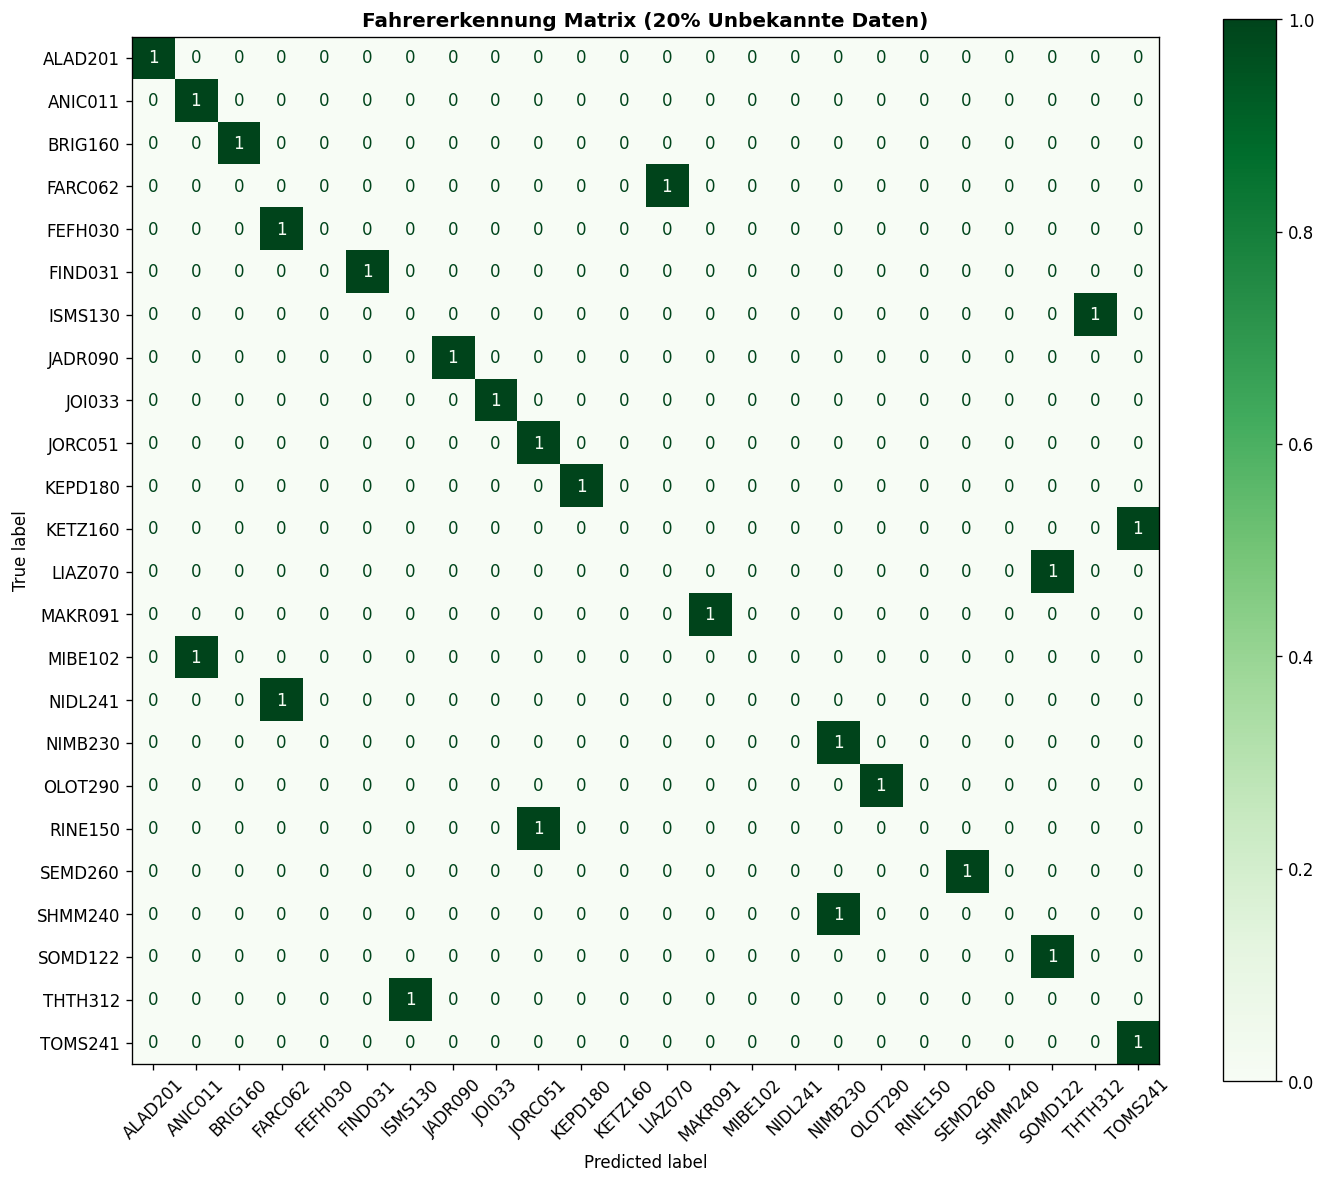

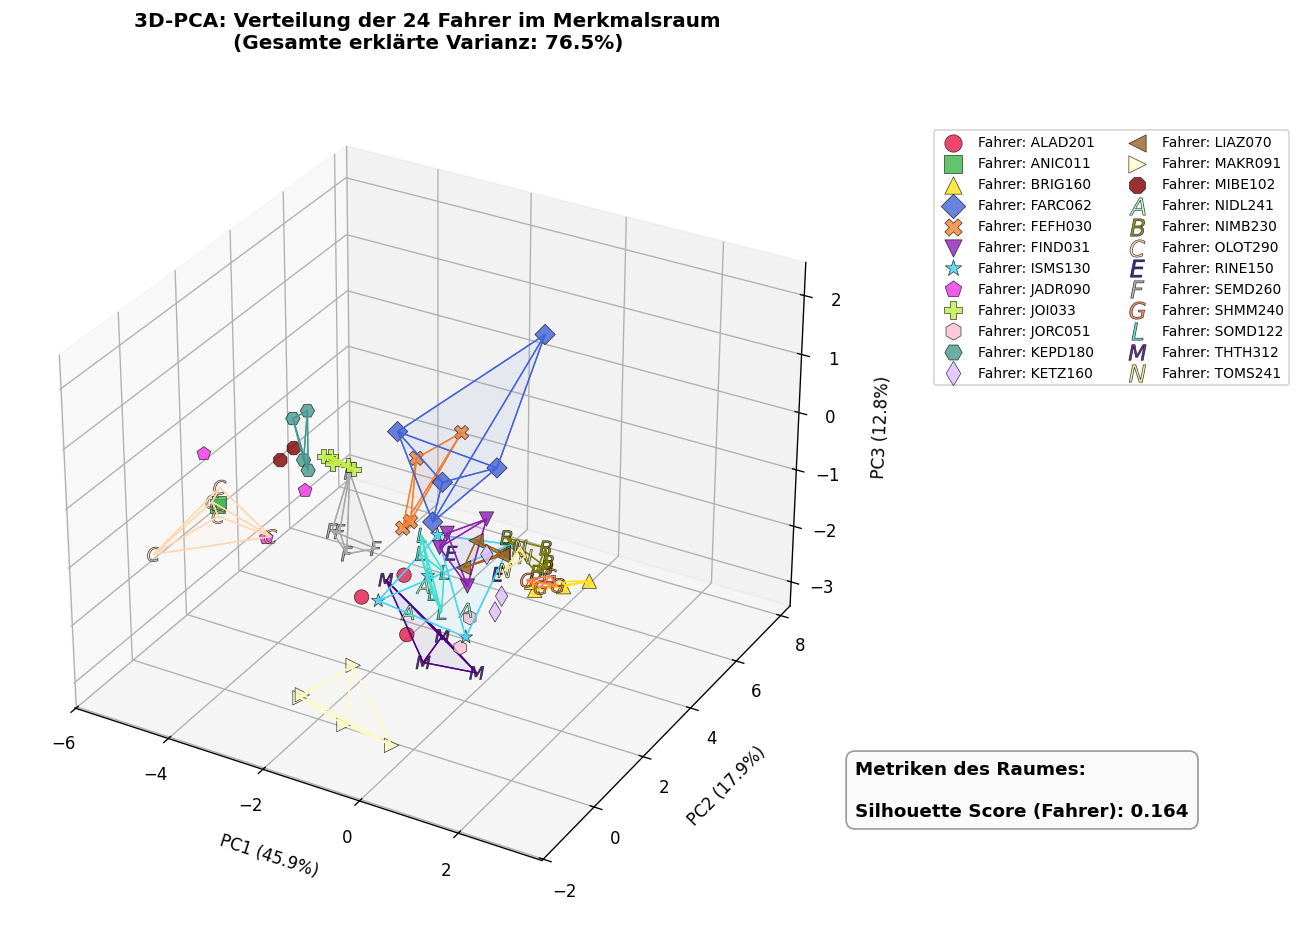

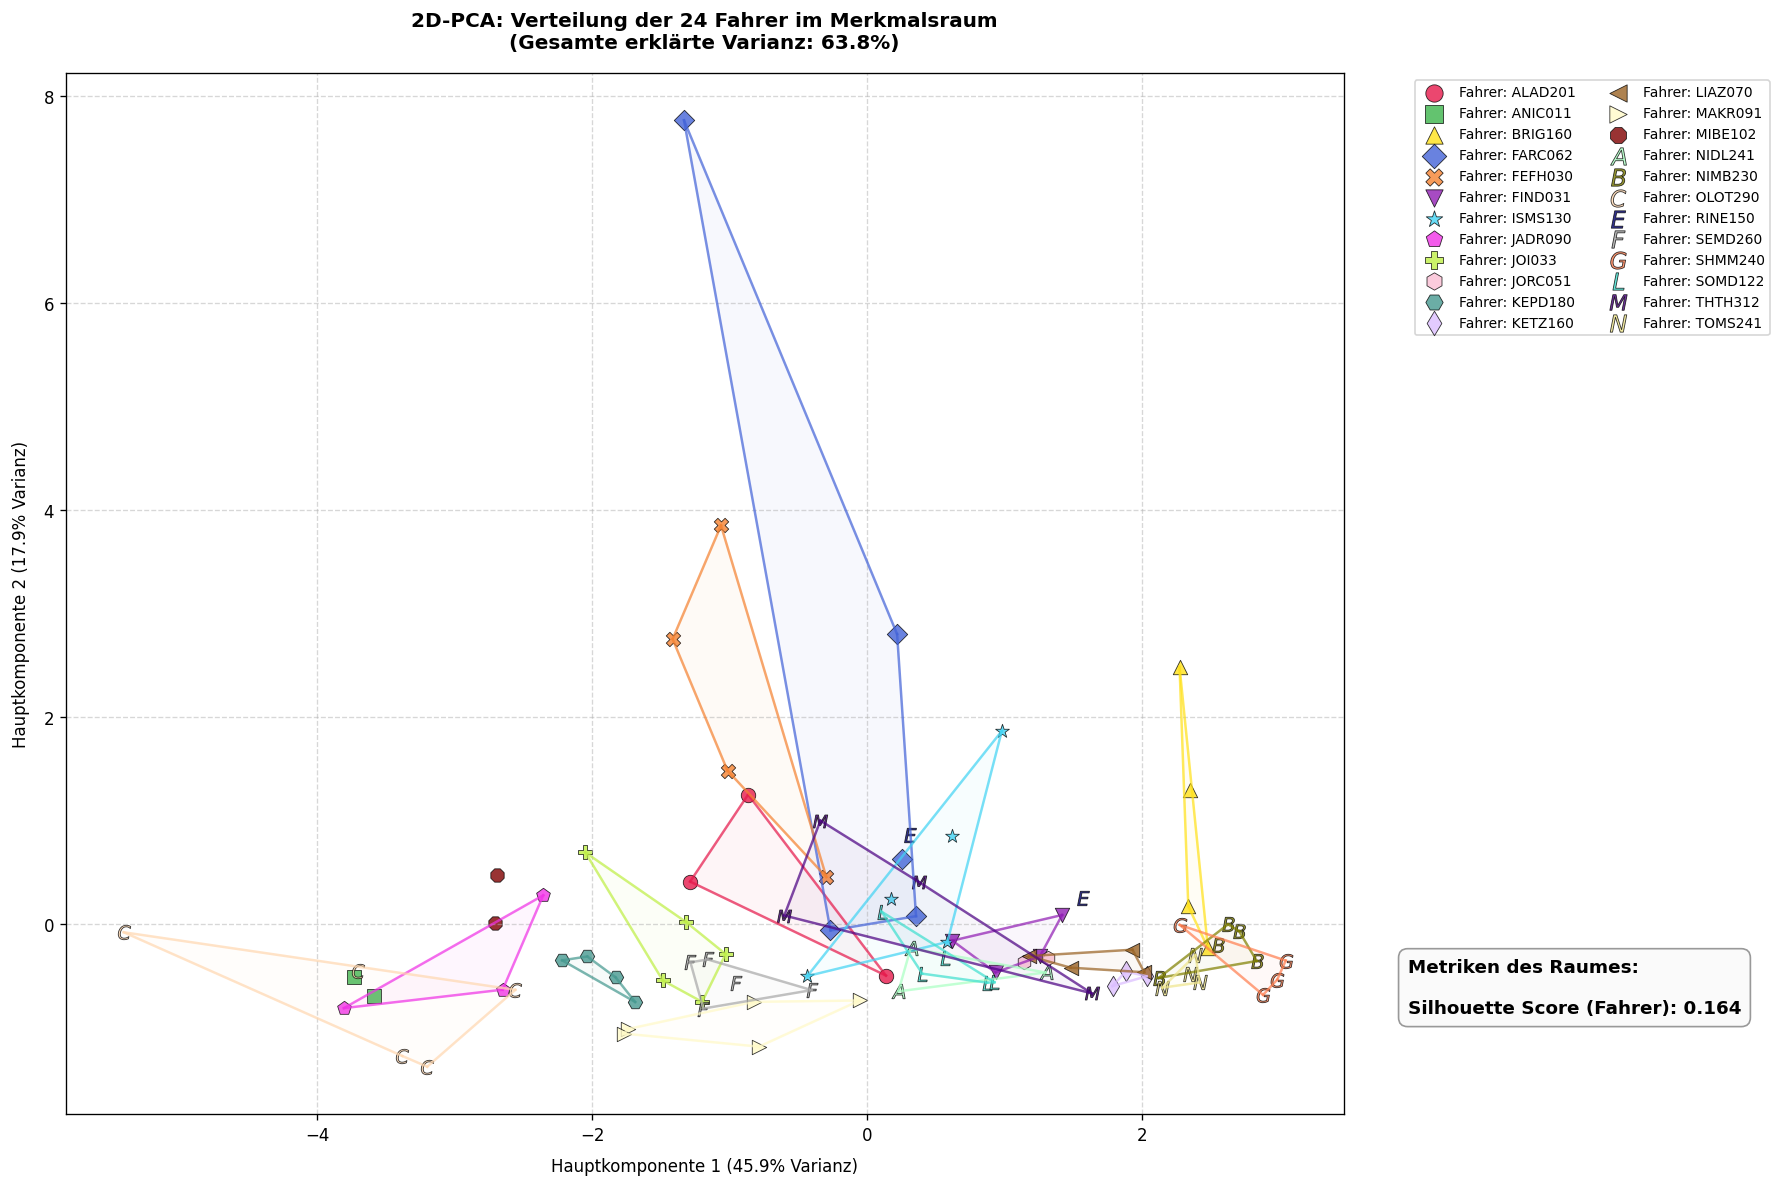


 Starte Fahrer-Wachstums-Analyse...
 -> Anzahl Fahrer:  2 | Test-Accuracy: 100.0%
 -> Anzahl Fahrer:  3 | Test-Accuracy: 100.0%
 -> Anzahl Fahrer:  4 | Test-Accuracy: 75.0%
 -> Anzahl Fahrer:  5 | Test-Accuracy: 80.0%
 -> Anzahl Fahrer:  6 | Test-Accuracy: 66.7%
 -> Anzahl Fahrer:  7 | Test-Accuracy: 71.4%
 -> Anzahl Fahrer:  8 | Test-Accuracy: 75.0%
 -> Anzahl Fahrer:  9 | Test-Accuracy: 66.7%
 -> Anzahl Fahrer: 10 | Test-Accuracy: 80.0%
 -> Anzahl Fahrer: 11 | Test-Accuracy: 72.7%
 -> Anzahl Fahrer: 12 | Test-Accuracy: 83.3%
 -> Anzahl Fahrer: 13 | Test-Accuracy: 69.2%
 -> Anzahl Fahrer: 14 | Test-Accuracy: 85.7%
 -> Anzahl Fahrer: 15 | Test-Accuracy: 35.7%
 -> Anzahl Fahrer: 16 | Test-Accuracy: 53.3%
 -> Anzahl Fahrer: 17 | Test-Accuracy: 37.5%
 -> Anzahl Fahrer: 18 | Test-Accuracy: 61.1%
 -> Anzahl Fahrer: 19 | Test-Accuracy: 66.7%
 -> Anzahl Fahrer: 20 | Test-Accuracy: 68.4%
 -> Anzahl Fahrer: 21 | Test-Accuracy: 60.0%
 -> Anzahl Fahrer: 22 | Test-Accuracy: 68.2%
 -> Anzahl Fahre

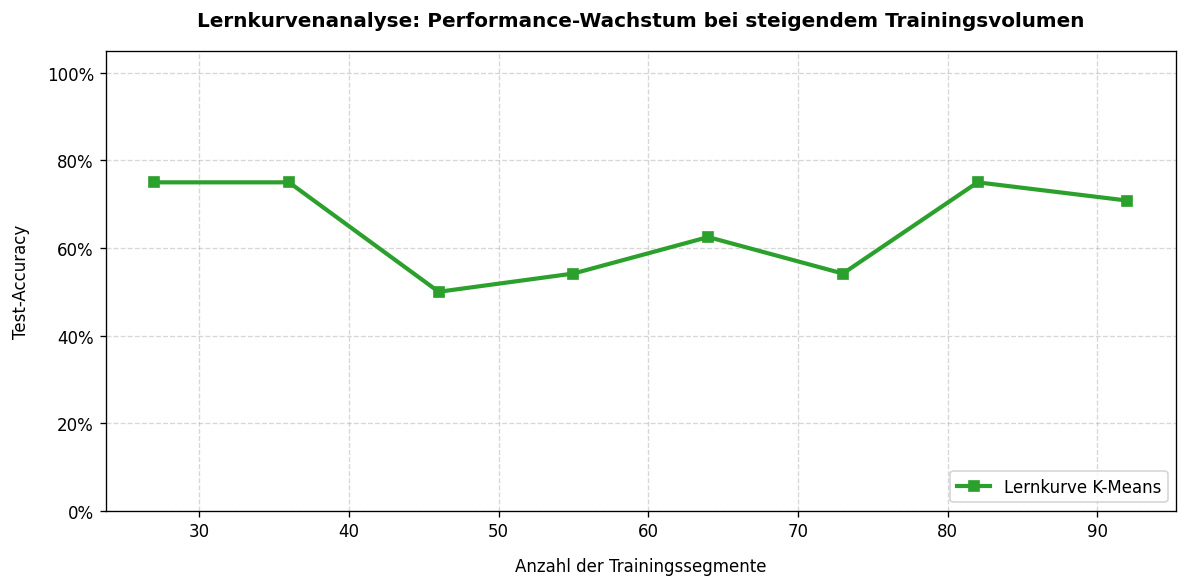

In [259]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, silhouette_score
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.spatial import ConvexHull
from scipy.optimize import linear_sum_assignment
import pandas as pd
import numpy as np

# Festgelegter Seed für absolute Reproduzierbarkeit auf jedem PC
RANDOM_SEED = 42

try:
    # --- 1. DATEN-SPLIT (80% Train, 20% Test auf den 10-Sekunden-Segmenten) ---
    train_df, test_df = train_test_split(
        df_master_ml, 
        test_size=0.2, 
        random_state=RANDOM_SEED, 
        stratify=df_master_ml['Fahrer_ID']
    )
    
    train_df = train_df.copy()
    test_df = test_df.copy()
    
    print(f"[Daten] Training (80% der 10s-Segmente): {len(train_df)}")
    print(f"[Daten] Test (20% der 10s-Segmente): {len(test_df)}")

    # Spalten, die keine Features sind, filtern
    spalten_zum_loeschen = [
        'Fahrer_ID', 'Segment_Nummer', 'Fahrstil_Cluster_ID', 
        'Vorhergesagter_Fahrer', 'Vorhergesagter_Cluster', 
        'Erkannter_Fahrer', 'Cluster_ID'
    ]
    
    X_train = train_df.drop(columns=spalten_zum_loeschen, errors='ignore')
    X_test = test_df.drop(columns=spalten_zum_loeschen, errors='ignore')

    # --- 2. SKALIEREN ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test) 

    # --- 3. K-MEANS TRAINING (NUR auf den 80%) ---
    num_drivers = train_df['Fahrer_ID'].nunique()  
    kmeans = KMeans(n_clusters=num_drivers, random_state=RANDOM_SEED, n_init=100)
    train_df['Cluster_ID'] = kmeans.fit_predict(X_train_scaled)

    # --- 4. LABEL-MAPPING (Ungarische Methode / Kuhn-Munkres) ---
    contingency_matrix = pd.crosstab(train_df['Fahrer_ID'], train_df['Cluster_ID'])
    cost_matrix = -contingency_matrix.values
    fahrer_indizes, cluster_indizes = linear_sum_assignment(cost_matrix)

    cluster_zu_fahrer = {}
    for f_idx, c_idx in zip(fahrer_indizes, cluster_indizes):
        echter_fahrer_name = contingency_matrix.index[f_idx]
        cluster_id = contingency_matrix.columns[c_idx]
        cluster_zu_fahrer[cluster_id] = echter_fahrer_name

    # --- 5. INFERENZ (Vorhersage auf den 20% Testdaten) ---
    test_df['Vorhergesagter_Cluster'] = kmeans.predict(X_test_scaled)
    test_df['Erkannter_Fahrer'] = test_df['Vorhergesagter_Cluster'].map(cluster_zu_fahrer)

    y_true_test = test_df['Fahrer_ID']
    y_pred_test = test_df['Erkannter_Fahrer']
    
    print("\n--- Ergebnis der 20% Testdaten ---")
    print(classification_report(y_true_test, y_pred_test, zero_division=0))

    # --- VORBEREITUNG DER VISUALISIERUNGEN (Globale Metrik & 25 feste Farb-/Symbol-Mappings) ---
    print("[Berechnung] Berechne Silhouette-Score für die echten Fahrer-IDs...")
    sil_score = silhouette_score(X_train_scaled, train_df['Fahrer_ID'])
    
    einzelne_fahrer = sorted(train_df['Fahrer_ID'].unique())
    
    # 25 manuell ausgewählte, maximal kontrastreiche Hex-Farben für das Beamer-Publikum
    feste_fahrer_farben = [
        '#e6194B', '#3cb44B', '#ffe119', '#4363d8', '#f58231', 
        '#911eb4', '#42d4f4', '#f032e6', '#bfef45', '#fabed4', 
        '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', 
        '#aaffc3', '#808000', '#ffd8b1', '#000075', '#a9a9a9',
        '#ff7f50', '#40e0d0', '#4b0082', '#f0e68c', '#dda0dd'
    ]
    
    # 25 eindeutige Marker (15 Formen + 10 saubere Vektor-Buchstaben)
    feste_fahrer_markers = [
        'o', 's', '^', 'D', 'X', 'v', '*', 'p', 'P', 'h', 'H', 'd', '<', '>', '8',
        '$A$', '$B$', '$C$', '$E$', '$F$', '$G$', '$L$', '$M$', '$N$', '$R$'
    ]

    color_mapping = {fahrer: feste_fahrer_farben[idx % len(feste_fahrer_farben)] for idx, fahrer in enumerate(einzelne_fahrer)}
    marker_mapping = {fahrer: feste_fahrer_markers[idx % len(feste_fahrer_markers)] for idx, fahrer in enumerate(einzelne_fahrer)}


    # --- GRAFIK 1: Confusion Matrix ---
    cm = confusion_matrix(y_true_test, y_pred_test)
    labels = sorted(y_true_test.unique())
    
    fig1, ax1 = plt.subplots(figsize=(12, 10), dpi=120)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=ax1, cmap=plt.cm.Greens, xticks_rotation=45)
    plt.title("Fahrererkennung Matrix (20% Unbekannte Daten)", fontweight='bold')
    plt.tight_layout()
    plt.show()


    # --- GRAFIK 2: Der 3-Dimensionale Fahrstil-Raum mit 3D Convex Hulls ---
    pca_3d = PCA(n_components=3)
    X_train_pca_3d = pca_3d.fit_transform(X_train_scaled)
    
    fig2 = plt.figure(figsize=(15, 9), dpi=120)
    ax2 = fig2.add_subplot(111, projection='3d')
    
    for fahrer in einzelne_fahrer:
        mask = train_df['Fahrer_ID'] == fahrer
        punkte_id = X_train_pca_3d[mask]
        
        if len(punkte_id) == 0:
            continue
            
        farbe = color_mapping[fahrer]
        marker = marker_mapping[fahrer]
        
        ax2.scatter(
            punkte_id[:, 0], punkte_id[:, 1], punkte_id[:, 2],
            color=farbe, marker=marker, s=75, edgecolor='k', linewidth=0.4, alpha=0.8,
            label=f"Fahrer: {fahrer}"
        )
        
        if len(punkte_id) >= 4:
            try:
                hull = ConvexHull(punkte_id)
                faces = [punkte_id[simplex] for simplex in hull.simplices]
                poly = Poly3DCollection(faces, facecolors=farbe, edgecolors=farbe, linewidths=0.8, alpha=0.03)
                ax2.add_collection3d(poly)
            except Exception:
                pass
    
    var_exp_3d = pca_3d.explained_variance_ratio_
    ax2.set_title(f"3D-PCA: Verteilung der {len(einzelne_fahrer)} Fahrer im Merkmalsraum\n(Gesamte erklärte Varianz: {sum(var_exp_3d):.1%})", fontweight='bold', pad=20)
    ax2.set_xlabel(f"PC1 ({var_exp_3d[0]:.1%})", labelpad=10)
    ax2.set_ylabel(f"PC2 ({var_exp_3d[1]:.1%})", labelpad=10)
    ax2.set_zlabel(f"PC3 ({var_exp_3d[2]:.1%})", labelpad=10)
    
    ax2.legend(loc='upper left', bbox_to_anchor=(1.1, 0.95), ncol=2, fontsize='small', markerscale=1.2)
    
    fig2.text(
        0.75, 0.20, f"Metriken des Raumes:\n\nSilhouette Score (Fahrer): {sil_score:.3f}",
        fontsize=11, fontweight='bold', bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9', edgecolor='gray', alpha=0.8)
    )
    plt.show()


    # --- GRAFIK 3: Der 2-Dimensionale Fahrstil-Raum mit 2D Convex Hulls ---
    pca_2d = PCA(n_components=2)
    X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)
    
    fig3, ax3 = plt.subplots(figsize=(15, 10), dpi=120)
    
    for fahrer in einzelne_fahrer:
        mask = train_df['Fahrer_ID'] == fahrer
        punkte_id = X_train_pca_2d[mask]
        
        if len(punkte_id) == 0:
            continue
            
        farbe = color_mapping[fahrer]
        marker = marker_mapping[fahrer]
        
        ax3.scatter(
            punkte_id[:, 0], punkte_id[:, 1],
            color=farbe, marker=marker, s=75, edgecolor='k', linewidth=0.5, alpha=0.8,
            label=f"Fahrer: {fahrer}"
        )
        
        if len(punkte_id) >= 3:
            try:
                hull = ConvexHull(punkte_id)
                for simplex in hull.simplices:
                    ax3.plot(punkte_id[simplex, 0], punkte_id[simplex, 1], color=farbe, linestyle='-', linewidth=1.5, alpha=0.7)
                ax3.fill(punkte_id[hull.vertices, 0], punkte_id[hull.vertices, 1], color=farbe, alpha=0.04)
            except Exception:
                pass
    
    var_exp_2d = pca_2d.explained_variance_ratio_
    ax3.set_title(f"2D-PCA: Verteilung der {len(einzelne_fahrer)} Fahrer im Merkmalsraum\n(Gesamte erklärte Varianz: {sum(var_exp_2d):.1%})", fontweight='bold', pad=15)
    ax3.set_xlabel(f"Hauptkomponente 1 ({var_exp_2d[0]:.1%} Varianz)", labelpad=8)
    ax3.set_ylabel(f"Hauptkomponente 2 ({var_exp_2d[1]:.1%} Varianz)", labelpad=8)
    ax3.grid(True, linestyle='--', alpha=0.5)
    
    ax3.legend(loc='upper left', bbox_to_anchor=(1.05, 1), bbox_transform=ax3.transAxes, ncol=2, fontsize='small', markerscale=1.2)
    
    ax3.text(
        1.05, 0.15, f"Metriken des Raumes:\n\nSilhouette Score (Fahrer): {sil_score:.3f}",
        transform=ax3.transAxes, fontsize=11, fontweight='bold', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#f9f9f9', edgecolor='gray', alpha=0.8)
    )
    plt.tight_layout()
    plt.show()


    # --- NIXONS FAHRER-WACHSTUM-SCHLEIFE & DIAGRAMM (EINGEBETTER MATHE-SCHUTZ) ---
    print("\n Starte Fahrer-Wachstums-Analyse...")
    fahrer_anzahl_liste = []
    accuracy_liste = []
    
    # Loop simuliert das Wachstum von 2 bis zur maximalen Anzahl an Fahrern
    for n in range(2, num_drivers + 1):
        ausgewaehlte_fahrer = einzelne_fahrer[:n]
        df_sub = df_master_ml[df_master_ml['Fahrer_ID'].isin(ausgewaehlte_fahrer)].copy()
        
        # BOMBENFESTER TRY-CATCH SCHUTZ FÜR DEN DATA-SPLIT BEI WENIG DATENPUNKTEN
        try:
            train_sub, test_sub = train_test_split(
                df_sub, 
                test_size=0.2, 
                random_state=RANDOM_SEED, 
                stratify=df_sub['Fahrer_ID']
            )
        except Exception:
            # Fallback, falls ein Fahrer zu wenige Zeilen hat und stratify fehlschlägt
            train_sub, test_sub = train_test_split(
                df_sub, 
                test_size=0.2, 
                random_state=RANDOM_SEED, 
                stratify=None
            )
        
        X_tr_s = scaler.fit_transform(train_sub.drop(columns=spalten_zum_loeschen, errors='ignore'))
        X_te_s = scaler.transform(test_sub.drop(columns=spalten_zum_loeschen, errors='ignore'))
        
        km_sub = KMeans(n_clusters=n, random_state=RANDOM_SEED, n_init=10)
        train_sub['Cluster_ID'] = km_sub.fit_predict(X_tr_s)
        
        cont_mat = pd.crosstab(train_sub['Fahrer_ID'], train_sub['Cluster_ID'])
        f_ind, c_ind = linear_sum_assignment(-cont_mat.values)
        map_sub = {cont_mat.columns[c]: cont_mat.index[f] for f, c in zip(f_ind, c_ind)}
        
        test_sub['Pred_Fahrer'] = pd.Series(km_sub.predict(X_te_s), index=test_sub.index).map(map_sub)
        
        acc = accuracy_score(test_sub['Fahrer_ID'], test_sub['Pred_Fahrer'])
        fahrer_anzahl_liste.append(n)
        accuracy_liste.append(acc)
        print(f" -> Anzahl Fahrer: {n:2d} | Test-Accuracy: {acc:.1%}")

    # --- DIAGRAMM B: NIXONS LERNKURVE (ROBUST GEGEN DATENMANGEL) ---
    print("\n[Simulation] Starte Nixons Lernkurven-Analyse (Segment-Wachstum)...")
    
    train_prozent_stufen = np.arange(0.1, 1.1, 0.1)
    segmente_anzahl_liste = []
    lernkurve_accuracy_liste = []
    
    # Fixer Test-Split (20%) vom kompletten Datensatz
    try:
        df_train_full, df_test_fixed = train_test_split(df_master_ml, test_size=0.2, random_state=RANDOM_SEED, stratify=df_master_ml['Fahrer_ID'])
    except:
        df_train_full, df_test_fixed = train_test_split(df_master_ml, test_size=0.2, random_state=RANDOM_SEED, stratify=None)
        
    X_test_fixed_scaled = scaler.fit_transform(df_test_fixed.drop(columns=spalten_zum_loeschen, errors='ignore'))
    
    for prozent in train_prozent_stufen:
        # Anteil der Trainingsdaten schneiden
        if prozent < 1.0:
            try:
                df_train_sub, _ = train_test_split(df_train_full, train_size=prozent, random_state=RANDOM_SEED, stratify=df_train_full['Fahrer_ID'])
            except:
                df_train_sub, _ = train_test_split(df_train_full, train_size=prozent, random_state=RANDOM_SEED, stratify=None)
        else:
            df_train_sub = df_train_full.copy()
            
        anzahl_segmente = len(df_train_sub)
        
        # SICHERHEITS-CHECK: Genug Daten für Cluster vorhanden?
        if anzahl_segmente < num_drivers:
            print(f" -> Genutzte Segmente: {anzahl_segmente:4d} | Zu wenig Daten für {num_drivers} Cluster, überspringe.")
            continue
        
        # Pipeline-Schritte
        X_tr_sub_scaled = scaler.fit_transform(df_train_sub.drop(columns=spalten_zum_loeschen, errors='ignore'))
        
        # Trainiere K-Means
        km_lern = KMeans(n_clusters=num_drivers, random_state=RANDOM_SEED, n_init=10)
        df_train_sub['Cluster_ID'] = km_lern.fit_predict(X_tr_sub_scaled)
        
        # Kuhn-Munkres Mapping
        c_mat = pd.crosstab(df_train_sub['Fahrer_ID'], df_train_sub['Cluster_ID'])
        f_i, c_i = linear_sum_assignment(-c_mat.values)
        mapping_lern = {c_mat.columns[c]: c_mat.index[f] for f, c in zip(f_i, c_i)}
        
        # Inferenz
        df_test_fixed['Pred_Fahrer'] = pd.Series(km_lern.predict(X_test_fixed_scaled), index=df_test_fixed.index).map(mapping_lern)
        
        # Accuracy
        acc_lern = accuracy_score(df_test_fixed['Fahrer_ID'], df_test_fixed['Pred_Fahrer'])
        
        segmente_anzahl_liste.append(anzahl_segmente)
        lernkurve_accuracy_liste.append(acc_lern)
        print(f" -> Genutzte Segmente: {anzahl_segmente:4d} ({prozent:.0%}) | Test-Accuracy: {acc_lern:.1%}")

    # Plot
    plt.figure(figsize=(10, 5), dpi=120)
    plt.plot(segmente_anzahl_liste, lernkurve_accuracy_liste, marker='s', linestyle='-', color='#2ca02c', linewidth=2.5, label="Lernkurve K-Means")
    plt.title("Lernkurvenanalyse: Performance-Wachstum bei steigendem Trainingsvolumen", fontweight='bold', pad=15)
    plt.xlabel("Anzahl der Trainingssegmente", labelpad=10)
    plt.ylabel("Test-Accuracy", labelpad=10)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(0, 1.05)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n[FAIL] Kritischer Fehler im Gesamt-Modul: {e}")